# Exploratory data analysis (EDA) 


Dataset: Immigration to Canada from 1980 to 2013 - [International migration flows to and from selected countries - The 2015 revision](http://www.un.org/en/development/desa/population/migration/data/empirical2/migrationflows.shtml?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDV0101ENSkillsNetwork20297740-2021-01-01) from United Nation's website.

In [1]:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

In [2]:
df = pd.read_excel('datasets/Canada.xlsx',
    sheet_name='Canada by Citizenship',
    skiprows=range(20),
    skipfooter=2,
                  engine = 'openpyxl')

In [3]:
df.head()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935,Asia,5501,Southern Asia,902,Developing regions,16,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Immigrants,Foreigners,Albania,908,Europe,925,Southern Europe,901,Developed regions,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Immigrants,Foreigners,Algeria,903,Africa,912,Northern Africa,902,Developing regions,80,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,Immigrants,Foreigners,American Samoa,909,Oceania,957,Polynesia,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
4,Immigrants,Foreigners,Andorra,908,Europe,925,Southern Europe,901,Developed regions,0,...,0,0,1,1,0,0,0,0,1,1


Let's find out how many entries there are in our dataset.


In [4]:
# print the dimensions of the dataframe
print(df.shape)

(195, 43)


## Clean up data


#### 1. Clean up the dataset to remove columns that are not informative to us for visualization (eg. Type, AREA, REG).


In [5]:
df.drop(['AREA', 'REG', 'DEV', 'Type', 'Coverage'], 
        axis=1, 
        inplace=True)

#### 2. Rename some of the columns so that they make sense.


In [6]:
df.rename(columns={'OdName':'Country', 
                   'AreaName':'Continent',
                   'RegName':'Region'}, 
          inplace=True)

#### 3. For consistency, ensure that all column labels of type string.


In [7]:
# let's examine the types of the column labels
all(isinstance(column, str) for column in df.columns)

False

Notice how the above line of code returned *False* when we tested if all the column labels are of type **string**. So let's change them all to **string** type.


In [8]:
df.columns = list(
    map(str, df.columns)
)

# let's check the column labels types now

all(
    isinstance(column, str) 
    for column in df.columns
)

True

#### 4. Set the country name as index - useful for quickly looking up countries using .loc method.


In [9]:
df.set_index('Country', 
             inplace=True
            )

#### 5. Add total column.


In [10]:
df['Total'] = df.iloc[:, 4:].sum(
    axis=1
)

In [11]:
# finally, let's create a list of years from 1980 - 2013
# this will come in handy when we start plotting the data

years = list(map(
    str, range(1980, 2014)
                )
            )

## Visualizing Data using Matplotlib


In [12]:
# use the inline backend to generate the plots within the browser
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('ggplot')  # optional: for ggplot-like style
print(plt.style.available)

# check for latest version of Matplotlib
print('Matplotlib version: ', mpl.__version__) # >= 2.0.0

['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']
Matplotlib version:  3.4.2


In [13]:
df.index.to_list()

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'China, Hong Kong Special Administrative Region',
 'China, Macao Special Administrative Region',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 "Côte d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 "Democratic People's Republic of Korea",
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'F

In [14]:
italia = df.loc['Italy', 
               years
              ] # passing in years 1980 - 2013 to exclude the 'total' column
italia.head()

1980    1820
1981    2057
1982    1480
1983     820
1984     858
Name: Italy, dtype: object

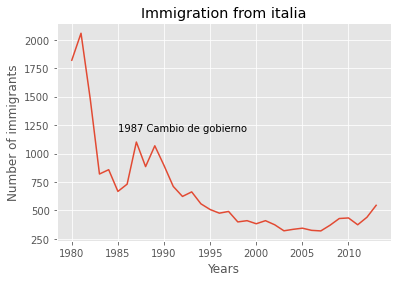

In [15]:
line_haiti = italia.plot()
#haiti.index = haiti.index.map(int) # let's change the index values of Haiti to type integer for plotting

###haiti.plot(kind='line')

plt.title('Immigration from italia')
plt.ylabel('Number of immigrants')
plt.xlabel('Years')

plt.text(5, 1200, '1987 Cambio de gobierno') # see note below

plt.show() 

In [16]:
### type your answer here
df_CI = df.loc[
              ['China', 'India'], 
                years
              ]
df_CI

#alternate 
#df_C = df.loc['China', years]
#df_I = df.loc['India', years]
#print(df_C)
#print(df_I)

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
China,5123,6682,3308,1863,1527,1816,1960,2643,2758,4323,...,36619,42584,33518,27642,30037,29622,30391,28502,33024,34129
India,8880,8670,8147,7338,5704,4211,7150,10189,11522,10343,...,28235,36210,33848,28742,28261,29456,34235,27509,30933,33087


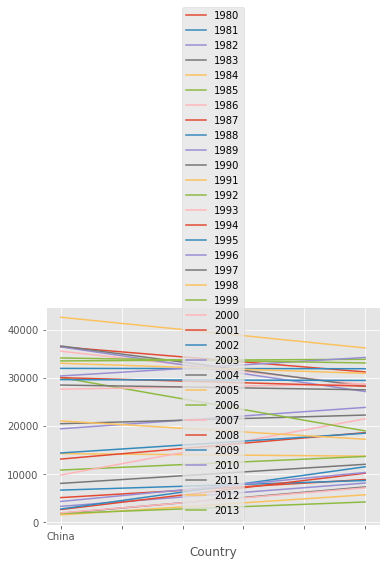

In [17]:
CI_line = df_CI.plot(kind='line')

In [18]:
df_CI = df_CI.transpose()
df_CI.head()

Country,China,India
1980,5123,8880
1981,6682,8670
1982,3308,8147
1983,1863,7338
1984,1527,5704


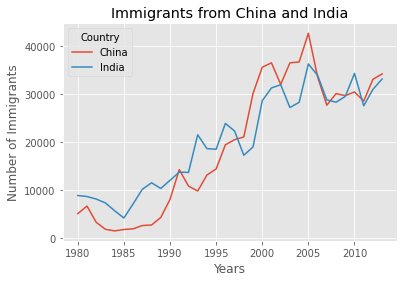

In [19]:
df_CI.index = df_CI.index.map(int) # let's change the index values of df_CI to type integer for plotting

df_CI.plot(kind='line')

plt.title('Immigrants from China and India')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show()

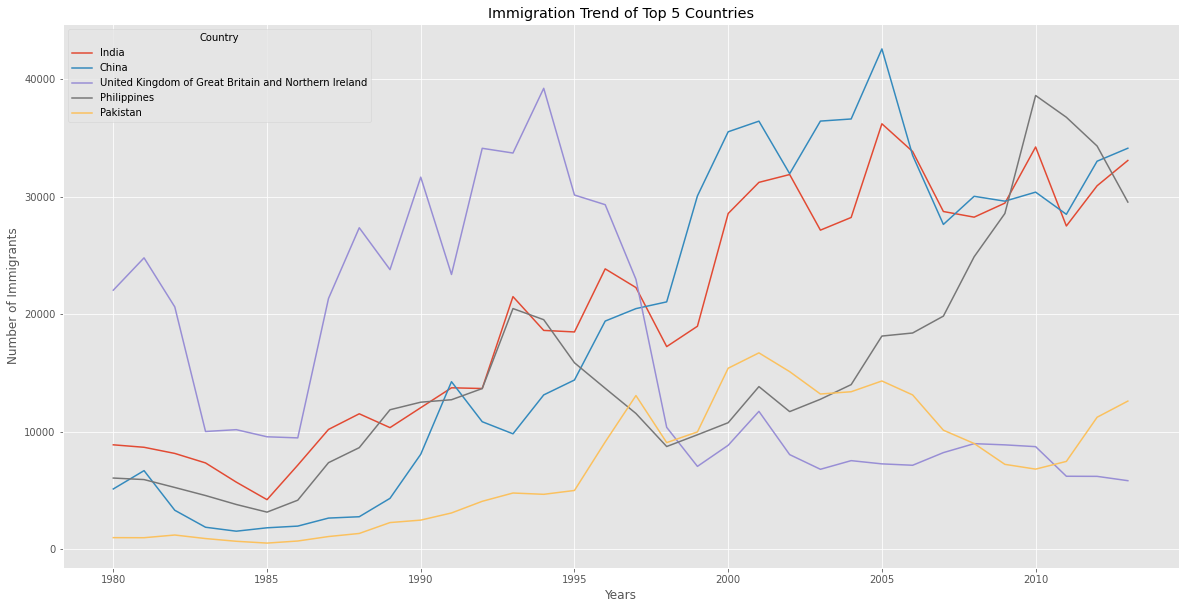

In [20]:
df_top = df.sort_values(by='Total', 
                        ascending=False, 
                        axis=0, 
                        inplace=False)

df_top.head()
df_top5 = df_top.head(5)
df_top5

df_top5 = df_top5[years].transpose()
df_top5

df_top5.index=df_top5.index.map(int)
df_top5.plot(kind='line', 
             figsize=(20,10))

plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show()

## Area Plots (Stacked Line Plot) 


In [21]:
df.sort_values(['Total'], ascending=False, axis=0, inplace=True)

# get the top 5 entries
df_top5 = df.head()

# transpose the dataframe
df_top5 = df_top5[years].transpose()

df_top5.head()

Country,India,China,United Kingdom of Great Britain and Northern Ireland,Philippines,Pakistan
1980,8880,5123,22045,6051,978
1981,8670,6682,24796,5921,972
1982,8147,3308,20620,5249,1201
1983,7338,1863,10015,4562,900
1984,5704,1527,10170,3801,668


*  Area plots are stacked by default. 
* To produce a stacked area plot, each column must be either all positive or all negative values (any `NaN`, i.e. not a number, values will default to 0). 

To produce an unstacked plot, set parameter `stacked` to value `False`.


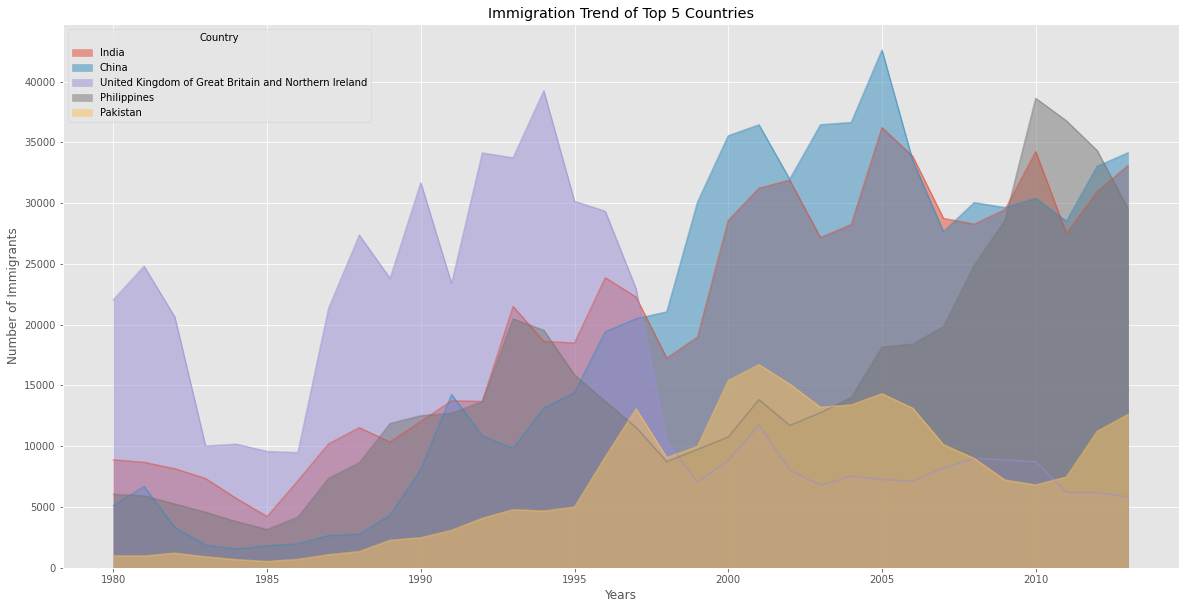

In [22]:
# let's change the index values of df_top5 to type integer for plotting

df_top5.index = df_top5.index.map(int)

df_top5.plot(kind='area',
             stacked=False,
             figsize=(20, 10))  # pass a tuple (x, y) size

plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show()

The unstacked plot has a default transparency (alpha value) at 0.5. We can modify this value by passing in the `alpha` parameter.


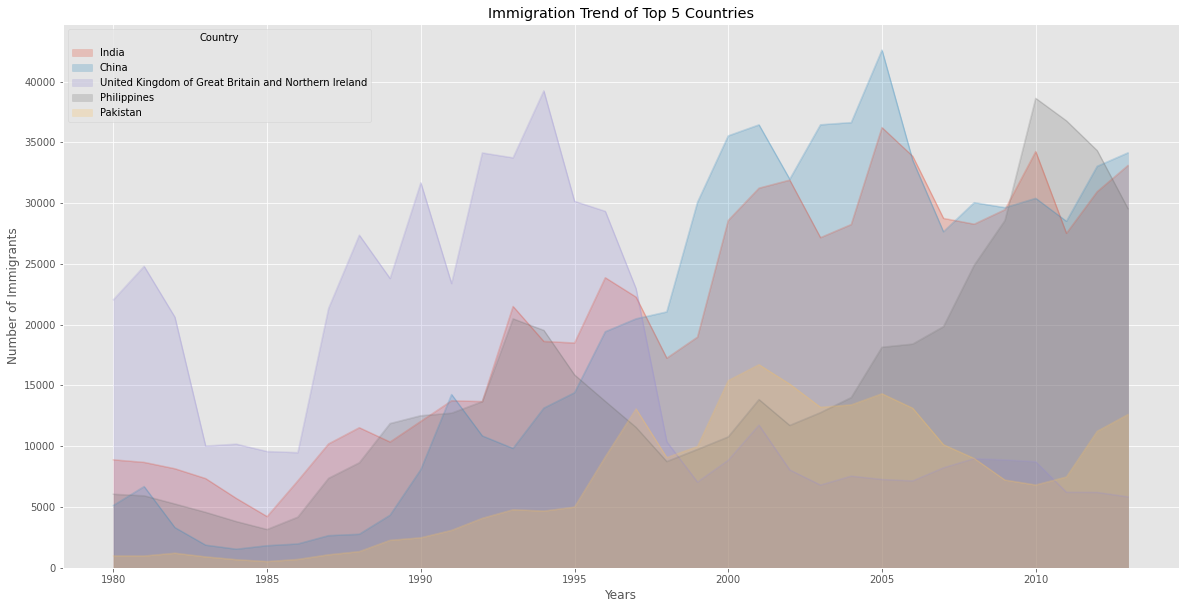

In [23]:
df_top5.plot(kind='area', 
             alpha=0.25,  # 0 - 1, default value alpha = 0.5
             stacked=False,
             figsize=(20, 10))

plt.title('Immigration Trend of Top 5 Countries')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show()

### Two types of plotting

There are two styles/options of plotting with `matplotlib`:
 
* plotting using the `Scripting layer`
* plotting using the `Artist layer`

**Option 1:** Scripting layer (procedural method) - using `matplotlib.pyplot` as `plt`

* You can use `plt` i.e. `matplotlib.pyplot`
* You can add more elements by calling different methods procedurally. 

For example, `plt.title(...)` to add title or `plt.xlabel(...)` to add label to the x-axis.

```python
    # Option 1: This is what we have been using so far
    df_top5.plot(kind='area', alpha=0.35, figsize=(20, 10)) 
    plt.title('Immigration trend of top 5 countries')
    plt.ylabel('Number of immigrants')
    plt.xlabel('Years')
```


**Option 2:** Artist layer (Object oriented method) - using an `Axes` instance from `matplotlib` (preferred)

*  You can use an `Axes` instance of your current plot and store it in a variable (eg. `ax`). 
*  You can add more elements by calling methods with a little change in syntax (by adding "`set_`" to the previous methods). 

For example, use `ax.set_title()` instead of `plt.title()` to add title,  or `ax.set_xlabel()` instead of `plt.xlabel()` to add label to the x-axis.

This option sometimes is more transparent and flexible to use for advanced plots (in particular when having multiple plots).

Text(0.5, 0, 'Years')

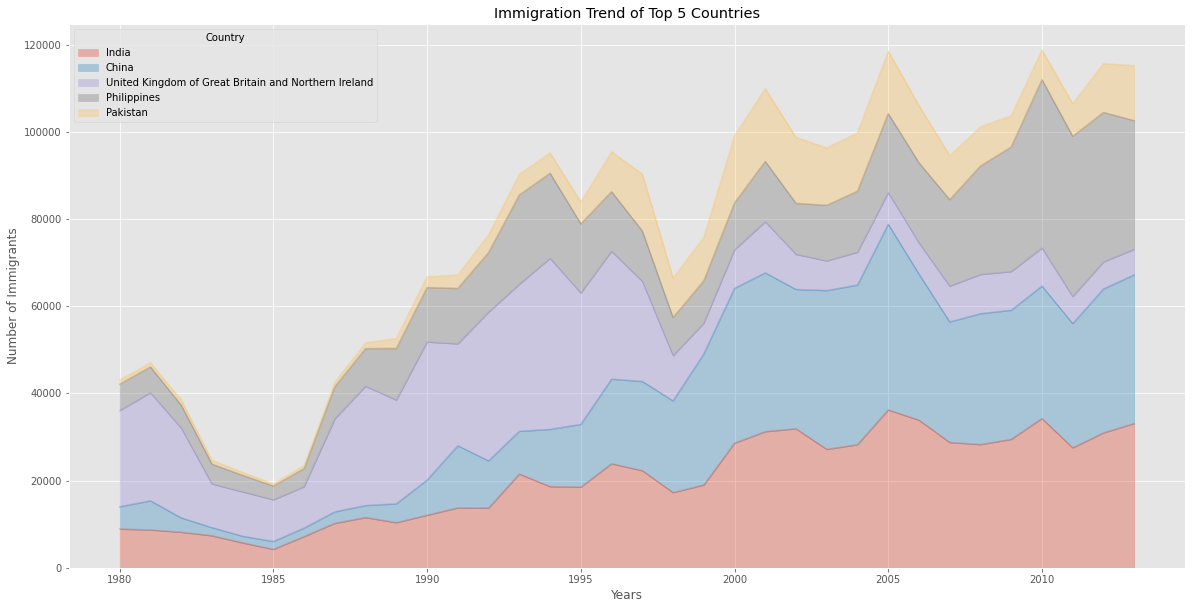

In [24]:
# option 2: preferred option with more flexibility
ax = df_top5.plot(kind='area', alpha=0.35, figsize=(20, 10))

ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Years')

**Question**: Use the scripting layer to create a stacked area plot of the 5 countries that contributed **the least** to immigration to Canada **from** 1980 to 2013. Use a transparency value of 0.45.


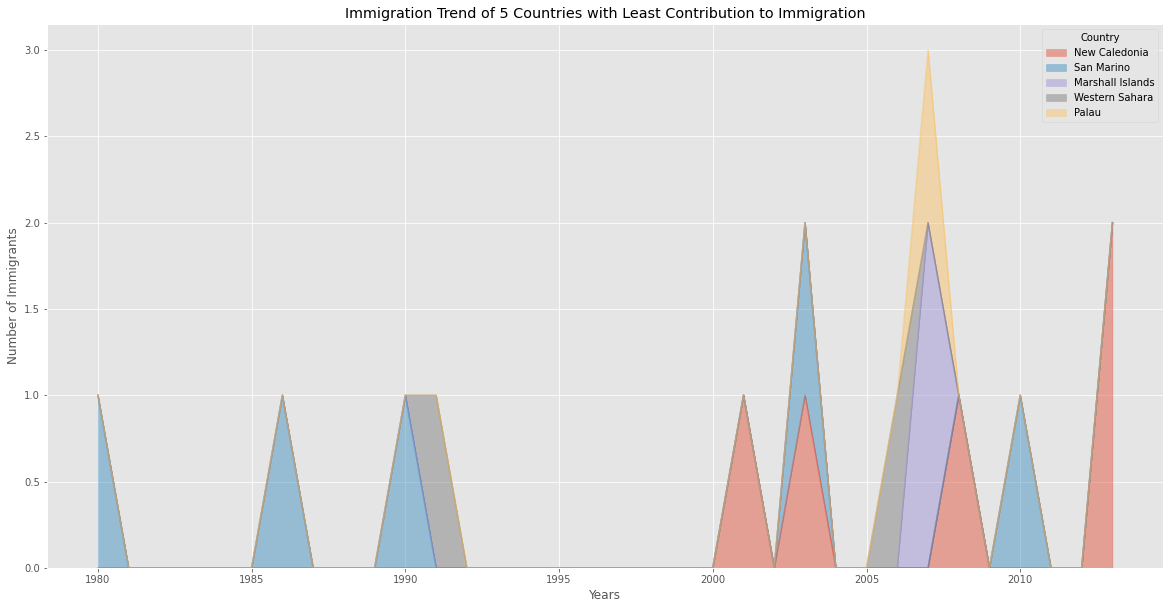

In [25]:
#<details><summary>Solution:</summary> 
    
least5 = df.tail(5)
least5 = least5[years].transpose()
least5.index = least5.index.map(int)

l5 = least5.plot(kind='area', alpha=0.45, figsize = (20, 10))

plt.title('Immigration Trend of 5 Countries with Least Contribution to Immigration')
plt.ylabel('Number of Immigrants')
plt.xlabel('Years')

plt.show() 

#</details>

**Question**: Use the artist layer to create an unstacked area plot of the 5 countries that contributed the least to immigration to Canada **from** 1980 to 2013. Use a transparency value of 0.55.


Text(0.5, 0, 'Years')

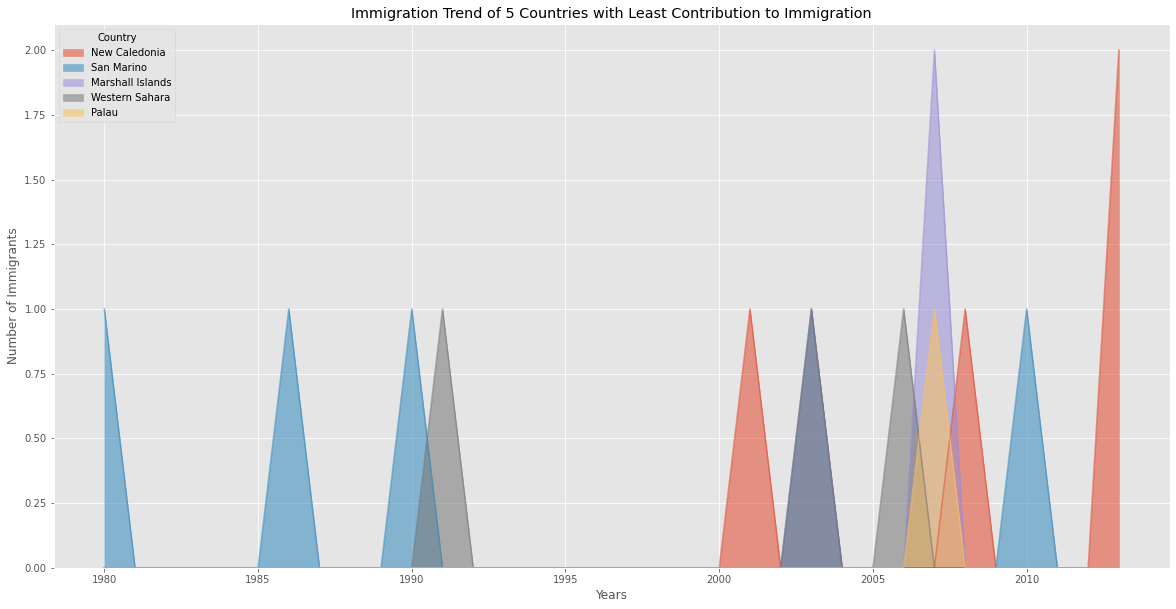

In [26]:
#<details><summary>Solution:</summary>  

# get the 5 countries with the least contribution
df_least5 = df.tail(5)

# transpose the dataframe
df_least5 = df_least5[years].transpose() 
    
#df_least5.head()

df_least5.index = df_least5.index.map(int) # let's change the index values of df_least5 to type integer for plotting
    
ax = df_least5.plot(kind='area', 
                    alpha=0.55, 
                    stacked=False, 
                    figsize=(20, 10))
    
ax.set_title('Immigration Trend of 5 Countries with Least Contribution to Immigration')
ax.set_ylabel('Number of Immigrants')
ax.set_xlabel('Years')
#</details>

## Histograms 

*  A histogram is a way of representing the *frequency* distribution of numeric dataset.
*  The way it works is it partitions the x-axis into *bins*, assigns each data point in our dataset to a bin, and then counts the number of data points that have been assigned to each bin. So the y-axis is the frequency or the number of data points in each bin. 


Note that we can change the bin size and usually one needs to tweak it so that the distribution is displayed nicely.

**Question:** What is the frequency distribution of the number (population) of new immigrants from the various countries to Canada in 2013?


* Before we proceed with creating the histogram plot, let's first examine the data split into intervals. 
* To do this, we will us **Numpy**'s `histrogram` method to get the bin ranges and frequency counts as follows:

In [27]:
df['2013'].head()

Country
India                                                   33087
China                                                   34129
United Kingdom of Great Britain and Northern Ireland     5827
Philippines                                             29544
Pakistan                                                12603
Name: 2013, dtype: int64

<AxesSubplot:ylabel='Frequency'>

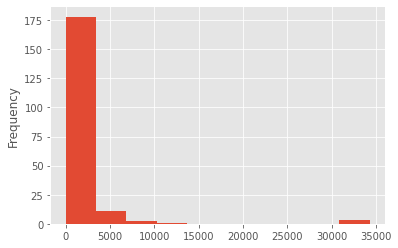

In [28]:
df['2012'].plot(kind = 'hist')

In [29]:
np.histogram(df['2012'])

(array([178,  11,   2,   1,   0,   0,   0,   0,   0,   3]),
 array([    0. ,  3431.5,  6863. , 10294.5, 13726. , 17157.5, 20589. ,
        24020.5, 27452. , 30883.5, 34315. ]))

By default, the `histrogram` method breaks up the dataset into 10 bins. 

In [30]:
# np.histogram returns 2 values
count, bin_edges = np.histogram(df['2013'])

print(count) # frequency count
print(bin_edges) # bin ranges, default = 10 bins

[178  11   1   2   0   0   0   0   1   2]
[    0.   3412.9  6825.8 10238.7 13651.6 17064.5 20477.4 23890.3 27303.2
 30716.1 34129. ]


The figure below summarizes the bin ranges and the frequency distribution of immigration in 2013. We can see that in 2013:

*   178 countries contributed between 0 to 3412.9 immigrants
*   11 countries contributed between 3412.9 to 6825.8 immigrants
*   1 country contributed between 6285.8 to 10238.7 immigrants, and so on..

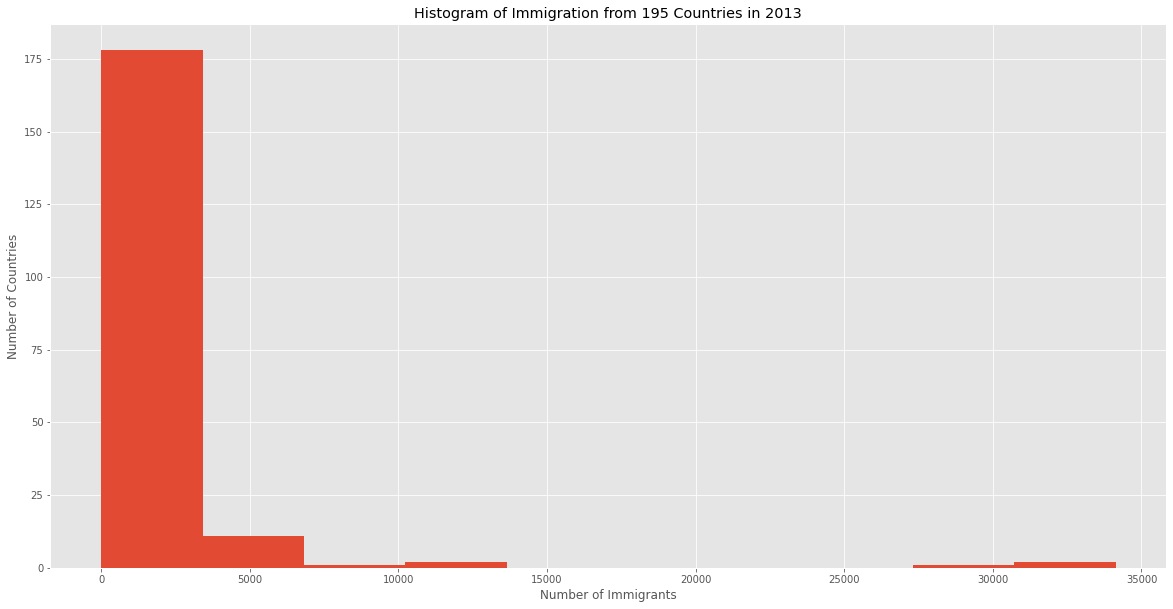

In [31]:
df['2013'].plot(kind='hist', figsize=(20, 10))


plt.title('Histogram of Immigration from 195 Countries in 2013')
plt.ylabel('Number of Countries')
plt.xlabel('Number of Immigrants')

plt.show()

* the x-axis represents the population range of immigrants in intervals of 3412.9. 
* the y-axis represents the number of countries that contributed to the aforementioned population.


* the x-axis labels do not match with the bin size. 
* passing in a `xticks` keyword with the `bin_edges`.


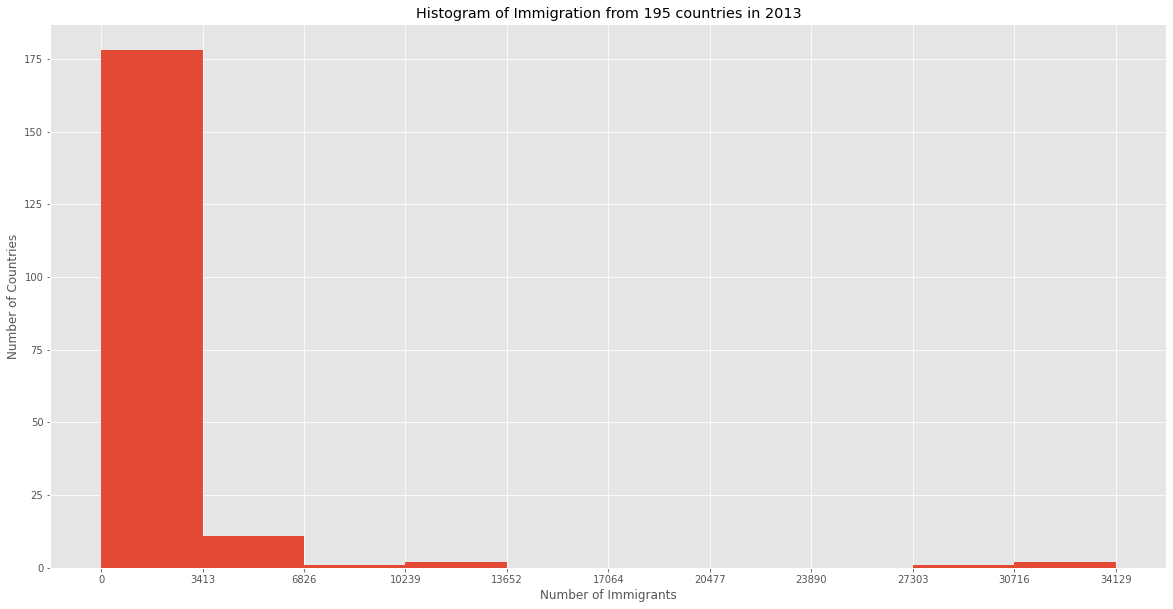

In [32]:
# 'bin_edges' is a list of bin intervals
count, bin_edges = np.histogram(df['2013'])

df['2013'].plot(kind='hist', 
                figsize=(20, 10), 
                xticks=bin_edges
               )

plt.title('Histogram of Immigration from 195 countries in 2013')  
plt.ylabel('Number of Countries')  
plt.xlabel('Number of Immigrants')  

plt.show()

Text(0.5, 0, 'Number of Immigrants')

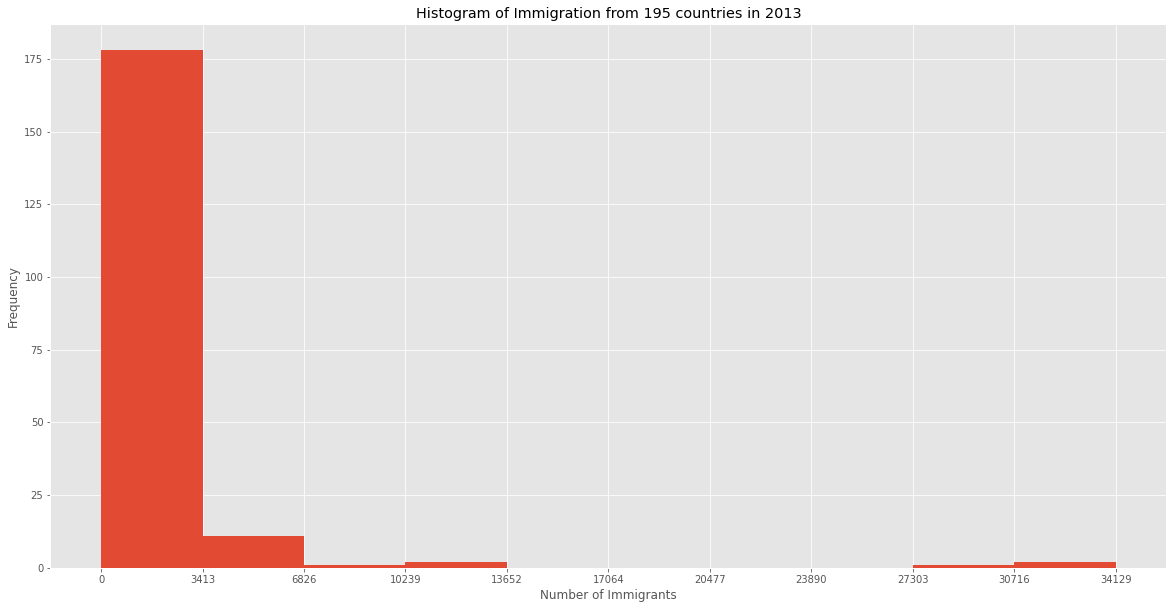

In [33]:
# Alternate 

a_hist=df['2013'].plot.hist(xticks=bin_edges,
                            figsize=(20, 10)
                           )
a_hist.set_title('Histogram of Immigration from 195 countries in 2013') 
a_hist.set_xlabel('Number of Immigrants')

# some_data.plot(kind='type_plot', ...) is equivalent to 
# some_data.plot.type_plot(...)



### Multiple histograms on the same plot

**Question**: What is the immigration distribution for Denmark, Norway, and Sweden for years 1980 - 2013?


In [34]:
# let's quickly view the dataset 
sel_countries = ['Denmark', 'Norway', 'Sweden']
df.loc[sel_countries, years]

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
Denmark,272,293,299,106,93,73,93,109,129,129,...,89,62,101,97,108,81,92,93,94,81
Norway,116,77,106,51,31,54,56,80,73,76,...,73,57,53,73,66,75,46,49,53,59
Sweden,281,308,222,176,128,158,187,198,171,182,...,129,205,139,193,165,167,159,134,140,140


<AxesSubplot:ylabel='Frequency'>

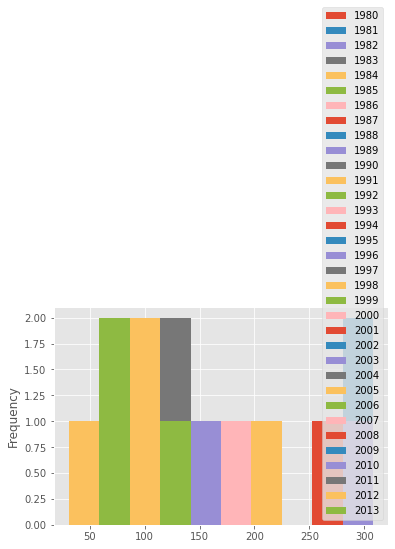

In [35]:
# generate histogram
df.loc[sel_countries, years].plot.hist()

That does not look right!

Don't worry, you'll often come across situations like this when creating plots. The solution often lies in how the underlying dataset is structured.

Instead of plotting the population frequency distribution of the population for the 3 countries, *pandas* instead plotted the population frequency distribution for the `years`.

This can be easily fixed by first transposing the dataset, and then plotting as shown below.


In [36]:
# transpose dataframe
df_t = df.loc[sel_countries, years].transpose()
df_t.head()

Country,Denmark,Norway,Sweden
1980,272,116,281
1981,293,77,308
1982,299,106,222
1983,106,51,176
1984,93,31,128


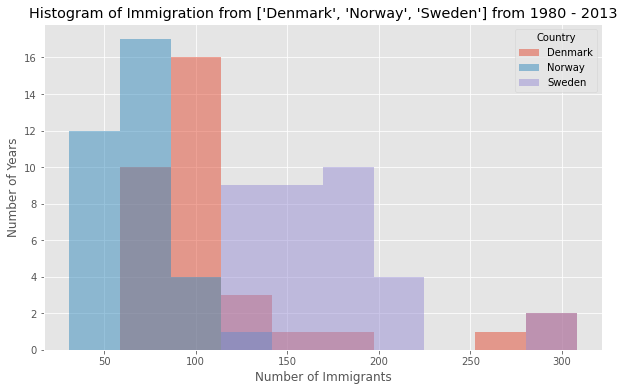

In [37]:
# generate histogram
df_t.plot(kind='hist', 
          figsize=(10, 6), 
          alpha = 0.5
         )

plt.title('Histogram of Immigration from {} from 1980 - 2013'.format(sel_countries))
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')

plt.show()

Let's make a *few modifications* to improve the impact and aesthetics of the previous plot:

*   increase the bin size to 15 by passing in `bins` parameter;
*   set transparency to 40% by passing in `alpha` parameter;
*   label the x-axis by passing in `x-label` parameter;
*   change the colors of the plots by passing in `color` parameter.


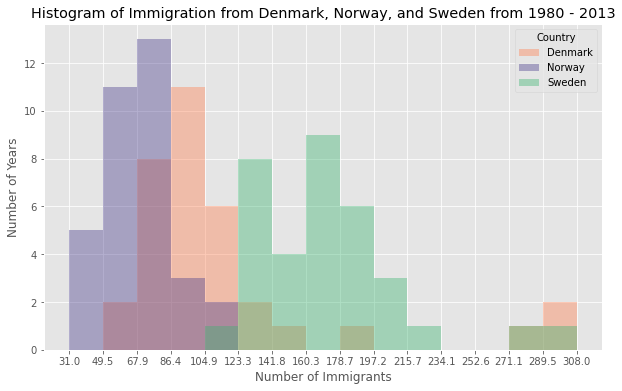

In [38]:
# let's get the x-tick values
count, bin_edges = np.histogram(df_t, 15)

# un-stacked histogram
df_t.plot(kind ='hist', 
          figsize=(10, 6),
          bins=15,
          alpha=0.4,
          xticks=bin_edges,
          color=['coral', 'darkslateblue', 'mediumseagreen']
         )

plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')

plt.show()

Tip:
For a full listing of colors available in Matplotlib, run the following code in your python shell:

```python
import matplotlib
for name, hex in matplotlib.colors.cnames.items():
    print(name, hex)
```


In [39]:
import matplotlib
for name, hex in matplotlib.colors.cnames.items():
    print(name, hex)

aliceblue #F0F8FF
antiquewhite #FAEBD7
aqua #00FFFF
aquamarine #7FFFD4
azure #F0FFFF
beige #F5F5DC
bisque #FFE4C4
black #000000
blanchedalmond #FFEBCD
blue #0000FF
blueviolet #8A2BE2
brown #A52A2A
burlywood #DEB887
cadetblue #5F9EA0
chartreuse #7FFF00
chocolate #D2691E
coral #FF7F50
cornflowerblue #6495ED
cornsilk #FFF8DC
crimson #DC143C
cyan #00FFFF
darkblue #00008B
darkcyan #008B8B
darkgoldenrod #B8860B
darkgray #A9A9A9
darkgreen #006400
darkgrey #A9A9A9
darkkhaki #BDB76B
darkmagenta #8B008B
darkolivegreen #556B2F
darkorange #FF8C00
darkorchid #9932CC
darkred #8B0000
darksalmon #E9967A
darkseagreen #8FBC8F
darkslateblue #483D8B
darkslategray #2F4F4F
darkslategrey #2F4F4F
darkturquoise #00CED1
darkviolet #9400D3
deeppink #FF1493
deepskyblue #00BFFF
dimgray #696969
dimgrey #696969
dodgerblue #1E90FF
firebrick #B22222
floralwhite #FFFAF0
forestgreen #228B22
fuchsia #FF00FF
gainsboro #DCDCDC
ghostwhite #F8F8FF
gold #FFD700
goldenrod #DAA520
gray #808080
green #008000
greenyellow #ADFF2F


* if we do not want the plots to overlap each other, we can stack them using the `stacked` parameter. 
* adjust the min and max x-axis labels to remove the extra gap on the edges of the plot. 

We can pass a tuple (min,max) using the `xlim` paramater.


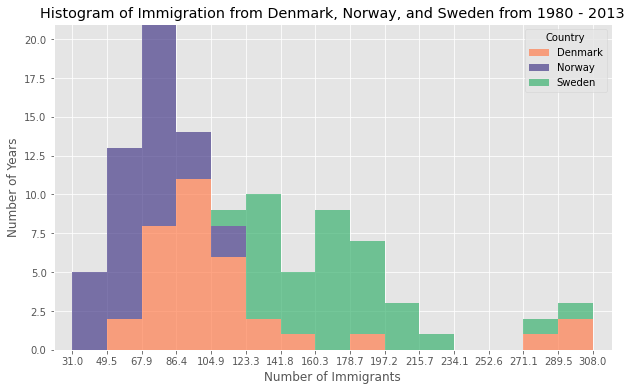

In [40]:
count, bin_edges = np.histogram(df_t, 15)

xmin = bin_edges[0] - 10   #  first bin value is 31.0, adding buffer of 10 for aesthetic purposes 
xmax = bin_edges[-1] + 10  #  last bin value is 308.0, adding buffer of 10 for aesthetic purposes

# stacked Histogram
df_t.plot(kind='hist',
          figsize=(10, 6), 
          bins=15,
          xticks=bin_edges,
          color=['coral', 'darkslateblue', 'mediumseagreen'],
          stacked=True,
          xlim=(xmin, xmax), 
          alpha=0.7
         )

plt.title('Histogram of Immigration from Denmark, Norway, and Sweden from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants') 

plt.show()

**Question**: Use the scripting layer to display the immigration distribution for Greece, Albania, and Bulgaria for years 1980 - 2013? Use an overlapping plot with 15 bins and a transparency value of 0.35.


In [41]:
fav_countries=['Greece', 'Albania', 'Bulgaria']
df_fav1 = df.loc[fav_countries, years].transpose()
df_fav1.head()

Country,Greece,Albania,Bulgaria
1980,1065,1,24
1981,953,0,20
1982,897,0,12
1983,633,0,33
1984,580,0,11


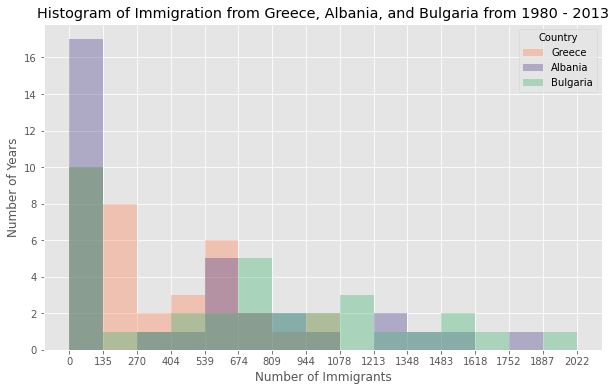

In [42]:
# let's get the x-tick values
count, bin_edges = np.histogram(df_fav1, 15)#default of binsize is 10, now we set to 15

# Un-stacked Histogram
df_fav1.plot(kind ='hist',
            figsize=(10, 6),
            bins=15,
            alpha=0.35,
            xticks=bin_edges,
            color=['coral', 'darkslateblue', 'mediumseagreen']
            )

plt.title('Histogram of Immigration from Greece, Albania, and Bulgaria from 1980 - 2013')
plt.ylabel('Number of Years')
plt.xlabel('Number of Immigrants')

plt.show()

## Bar Charts (Dataframe) 

*  The *length* of the bars represents the magnitude/size of the feature/variable. 
*  Bar graphs usually represent numerical and categorical variables grouped in intervals.

To create a bar plot, we can pass one of two arguments via `kind` parameter in `plot()`:

*   `kind=bar` creates a *vertical* bar plot
*   `kind=barh` creates a *horizontal* bar plot


**Vertical bar plot**

* the x-axis is used for labelling
* the length of bars on the y-axis corresponds to the magnitude of the variable being measured. 

Vertical bar graphs are particularly useful in analyzing time series data. 
One disadvantage is that they lack space for text labelling at the foot of each bar.




**Question:** Compare the number of Icelandic immigrants (country = 'Iceland') to Canada from year 1980 to 2013.


In [43]:
# step 1: get the data
df_iceland = df.loc['Iceland', years]
df_iceland.head()

1980    17
1981    33
1982    10
1983     9
1984    13
Name: Iceland, dtype: object

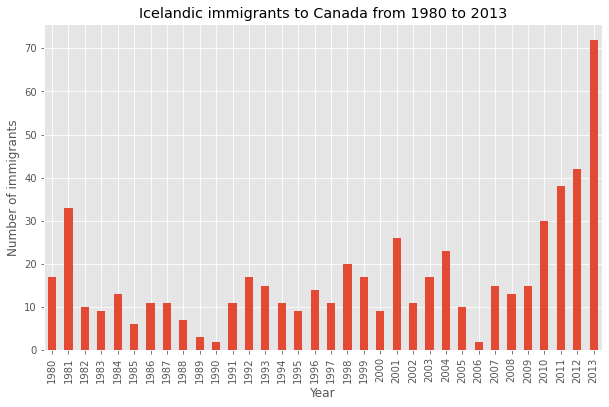

In [44]:
# step 2: plot data
df_iceland.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Year') # add to x-label to the plot
plt.ylabel('Number of immigrants') # add y-label to the plot
plt.title('Icelandic immigrants to Canada from 1980 to 2013') # add title to the plot

plt.show()

*  the bar plot above shows the total number of immigrants broken down by each year.
*  the number of immigrants to Canada started increasing rapidly after 2008.

Let's annotate this on the plot using the `annotate` method of the **scripting layer** or the **pyplot interface**. We will pass in the following parameters:

*   `s`: str, the text of annotation.
*   `xy`:  specifying the (x,y) point to annotate (in this case, end point of arrow).
*   `xytext`:  specifying the (x,y) point to place the text (in this case, start point of arrow).
*   `xycoords`:  coordinate system that xy is given in - 'data' uses the coordinate system of the object being annotated (default).
*   `arrowprops`: takes a dictionary of properties to draw the arrow:
    *   `arrowstyle`: specifies the arrow style, `'->'` is standard arrow.
    *   `connectionstyle`: specifies the connection type. `arc3` is a straight line.
    *   `color`: specifies color of arrow.
    *   `lw`: specifies the line width.

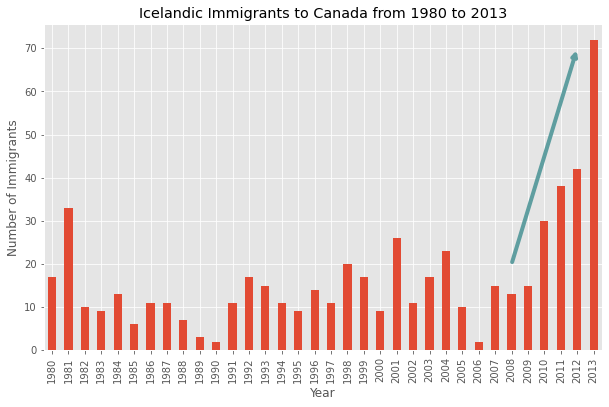

In [45]:
df_iceland.plot(kind='bar', 
                figsize=(10, 6), 
                rot=90)  # rotate the xticks(labelled points on x-axis) by 90 degrees

plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.title('Icelandic Immigrants to Canada from 1980 to 2013')

# Annotate arrow
plt.annotate('',  # s: str. Will leave it blank for no text
             xy=(32, 70),  # place head of the arrow at point (year 2012 , pop 70)
             xytext=(28, 20),  # place base of the arrow at point (year 2008 , pop 20)
             xycoords='data',  # will use the coordinate system of the object being annotated
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='cadetblue', lw=4)
             )

plt.show()

Let's also annotate a text to go over the arrow.  We will pass in the following additional parameters:

*   `rotation`: rotation angle of text in degrees (counter clockwise)
*   `va`: vertical alignment of text \[‘center’ | ‘top’ | ‘bottom’ | ‘baseline’]
*   `ha`: horizontal alignment of text \[‘center’ | ‘right’ | ‘left’]


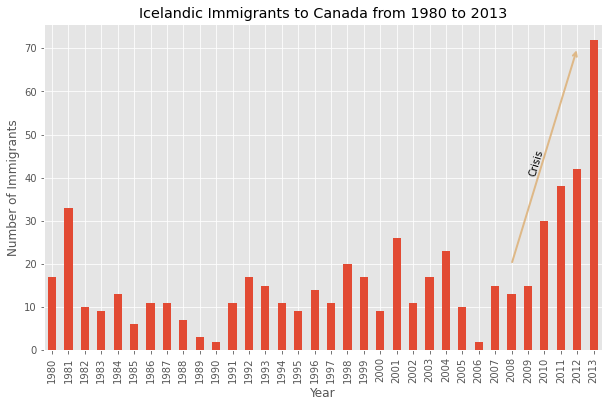

In [46]:
df_iceland.plot(kind='bar', 
                figsize=(10, 6), 
                rot=90)

plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.title('Icelandic Immigrants to Canada from 1980 to 2013')

# Annotate arrow
plt.annotate('',  # s: str. will leave it blank for no text
             xy=(32, 70),  # place head of the arrow at point (year 2012 , pop 70)
             xytext=(28, 20),  # place base of the arrow at point (year 2008 , pop 20)
             xycoords='data',  # will use the coordinate system of the object being annotated
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='burlywood', lw=2)
             )

# Annotate Text
plt.annotate('Crisis',  # text to display
             xy=(29, 40),  # start the text at at point (year 2008 , pop 30)
             rotation=73.5,  # based on trial and error to match the arrow
             va='bottom',  # want the text to be vertically 'bottom' aligned
             ha='left',  # want the text to be horizontally 'left' algned.
             )

plt.show()

**Horizontal Bar Plot**

* the y-axis is used for labelling
* the length of bars on the x-axis corresponds to the magnitude of the variable being measured. 

**Question:** Using the scripting later, create a *horizontal* bar plot showing the *total* number of immigrants to Canada from the top 15 countries, for the period 1980 - 2013. Label each country with the total immigrant count.


Step 1: Get the data pertaining to the top 15 countries.


In [47]:
### type your answer here
df.sort_values(by='Total', ascending=True, inplace=True)
top15 = df['Total'].tail(15)
top15 

Country
Romania                                                  93210
Viet Nam                                                 95955
Jamaica                                                 103233
France                                                  107362
Lebanon                                                 113950
Poland                                                  138378
Republic of Korea                                       141570
Sri Lanka                                               148173
Iran (Islamic Republic of)                              174751
United States of America                                231744
Pakistan                                                240622
Philippines                                             505340
United Kingdom of Great Britain and Northern Ireland    529455
China                                                   654839
India                                                   683024
Name: Total, dtype: int64

Step 2: Plot data:

1.  Use `kind='barh'` to generate a bar chart with horizontal bars.
2.  Make sure to choose a good size for the plot and to label your axes and to give the plot a title.
3.  Loop through the countries and annotate the immigrant population using the anotate function of the scripting interface.


In [48]:
colors = ['red', 'blue', 'green']

for i, color in enumerate(colors): 
    print('color id {} is {}'.format(i, color))

color id 0 is red
color id 1 is blue
color id 2 is green


In [49]:
type(top15)

pandas.core.series.Series

# top15

for country, count in enumerate(top15): 
    print('Country {} had {} emmigrants'.format(country, count))

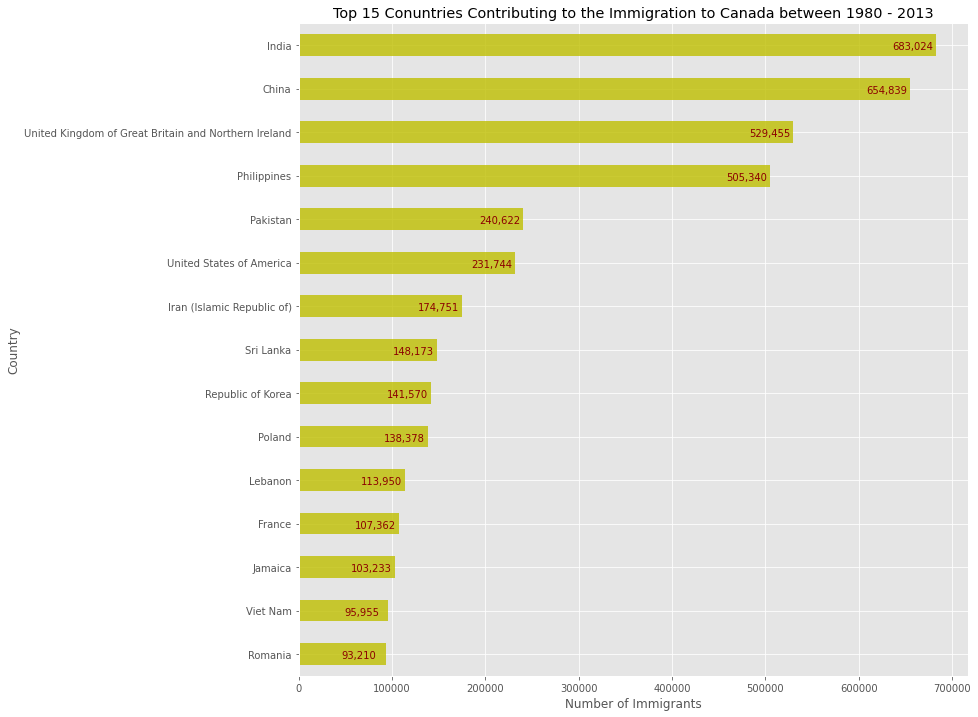

In [50]:
# generate plot
top15.plot(kind='barh', 
           figsize=(12, 12), 
           color='y',
           alpha=0.8
          )

plt.xlabel('Number of Immigrants')
plt.title('Top 15 Conuntries Contributing to the Immigration to Canada between 1980 - 2013')

# annotate value labels to each country
for index, value in enumerate(top15): 
    label = format(int(value), ',') # format int with commas
    
    # placing text at the end of bar (subtracting 47000 from x, and 0.1 from y to make it fit within the bar)
    plt.annotate(label, 
             xy=(value - 47000, index - 0.10), 
             color='darkred'
            )

##aquamarine #7FFFD4
##azure #F0FFFF
##beige #F5F5DC
##bisque #FFE4C4

plt.show()

In [51]:
import seaborn as sns

In [52]:
ndf = df.iloc[:10, :10]
ndf

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986
Country,,,,,,,,,,
Palau,Oceania,Micronesia,Developing regions,0,0,0,0,0,0,0
Western Sahara,Africa,Northern Africa,Developing regions,0,0,0,0,0,0,0
Marshall Islands,Oceania,Micronesia,Developing regions,0,0,0,0,0,0,0
San Marino,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1
New Caledonia,Oceania,Melanesia,Developing regions,0,0,0,0,0,0,0
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0
Tuvalu,Oceania,Polynesia,Developing regions,0,1,0,0,1,0,0
Sao Tome and Principe,Africa,Middle Africa,Developing regions,0,0,0,0,0,0,0
Vanuatu,Oceania,Melanesia,Developing regions,0,0,0,0,0,0,0


In [53]:
ndf.corr()

,1980,1981,1982,1983,1984,1985,1986
1980,1.000000,-0.166667,NaN,-0.111111,-0.111111,NaN,1.000000
1981,-0.166667,1.000000,NaN,-0.166667,0.666667,NaN,-0.166667
1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983,-0.111111,-0.166667,NaN,1.000000,-0.111111,NaN,-0.111111
1984,-0.111111,0.666667,NaN,-0.111111,1.000000,NaN,-0.111111
1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986,1.000000,-0.166667,NaN,-0.111111,-0.111111,NaN,1.000000


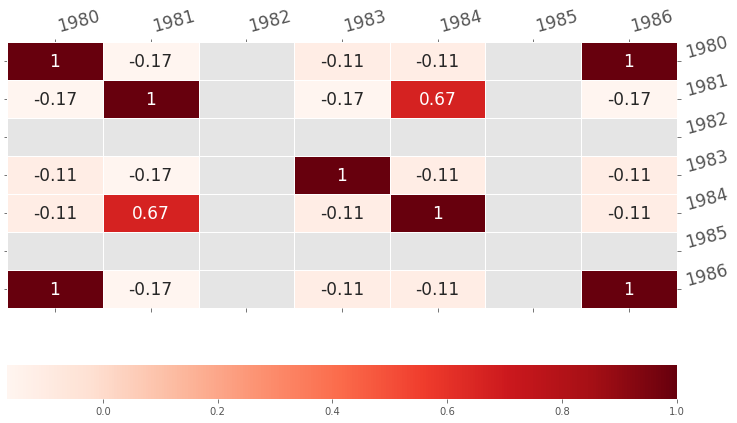

In [54]:
hm = plt.subplots(figsize=(12, 7))
hm = sns.heatmap(ndf.corr(), 
           annot = True, 
           linewidth=0.5,
            cmap = 'Reds', #Blues, Greens, YlGnBu, YlGnBu, PiYG,
            annot_kws={"size": 17}, 
                 cbar_kws={"orientation": "horizontal"},
           )

hm.set_yticklabels(hm.get_ymajorticklabels(), 
                   fontsize = 17, 
                  )
hm.set_yticklabels(hm.get_ymajorticklabels(), 
                   fontsize = 17, 
                   rotation = 15
                  )
hm.tick_params(#axis='y', 
               right=True,  # a line will appear if it is true 
               labelleft=False, 
               labelright=True, 
              )
#to place the top lables in 'left' position
ylables = hm.get_yticklabels()#which='both')
for i in ylables:
    i.set_va('bottom')

hm.set_xticklabels(hm.get_xmajorticklabels(), 
                   fontsize = 17, 
                   rotation = 15
                  )
hm.tick_params(#axis='x', 
               top=True,  # a line will appear if it is true 
               labeltop=True, 
               labelbottom=False, 
              )

#to place the top lables in 'left' position
ticklbls = hm.get_xticklabels()#which='both')
for x in ticklbls:
    x.set_ha('left')

<!--NAVIGATION-->
< [Previous](https://github.com) 
| [Toc](https://github.com) 
| [Next](https://github.com) >